# Credit Risk Early Warning System
## Notebook 04 — Risk Segmentation, Expected Loss & Risk-Based Pricing

This notebook turns the Phase D champion model — **Calibrated CatBoost** (Brier Score
0.2127 -> 0.1603 via isotonic calibration) — into lending decisions. No new models, no
further tuning, no new feature engineering. The calibrated probability is treated as the
official **Probability of Default (PD)** and used as-is.

**What this notebook answers:**
1. How should borrowers be segmented by risk?
2. What is the expected loss of each borrower?
3. What price should be charged for risk?
4. What does portfolio risk look like?
5. How would a lending institution use these outputs?

The working portfolio is the **2016 validation cohort** (293,095 resolved loans) — the same
population the calibration step was fit on, so calibrated PDs are most directly applicable.


---
## Section 0 — Setup: Load Champion Model & Working Portfolio

Reproduce the same preprocessing / feature engineering / time-based split as
`03_modeling.ipynb`, then load the saved Calibrated CatBoost model and score the 2016
validation cohort. This score (`pd_score`) is the official PD used throughout this notebook.


In [1]:
import sys
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

from preprocessing import prepare_data
from features import create_all_features, FINAL_MODEL_FEATURES

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

COLOR_DEFAULT    = '#c0392b'
COLOR_NONDEFAULT = '#2980b9'
COLOR_NEUTRAL    = '#7f8c8d'
PALETTE_RISK     = 'Reds'

print('Setup complete.')


C:\Users\zayan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup complete.


In [2]:
def load_lending_club_data(search_dirs=None):
    """Locate and load the LendingClub CSV (plain or gzip-compressed)."""
    if search_dirs is None:
        base = os.path.join(os.getcwd(), '..')
        search_dirs = [os.path.join(base, 'datasets', 'data'), os.path.join(base, 'datasets'),
                       os.path.join(base, 'data'), base]

    for directory in search_dirs:
        for pattern in ['*.csv', '*.csv.gz']:
            matches = sorted(glob.glob(os.path.join(directory, pattern)))
            matches = [m for m in matches if 'rejected' not in os.path.basename(m).lower()]
            if matches:
                path = matches[0]
                print(f'Loading: {path}')
                return pd.read_csv(path, low_memory=False)

    raise FileNotFoundError('No CSV or CSV.GZ file found in datasets/ or data/.')


output_dir = os.path.join(os.getcwd(), '..', 'outputs')
models_dir = os.path.join(os.getcwd(), '..', 'models')

raw_df = load_lending_club_data()
clean_df = prepare_data(raw_df.copy(), output_dir=output_dir)
df = create_all_features(clean_df.copy(), output_dir=output_dir)

# Same time-based split as 03_modeling.ipynb
val_df = df[df['issue_year'] == 2016].copy().reset_index(drop=True)
print(f'Working portfolio (2016 validation cohort): {len(val_df):,} loans, '
      f'default rate {val_df["target"].mean():.2%}')


Loading: E:\Resume -- Projects\Credit Risk Early Warning & Risk-Based Loan Pricing Engine\notebooks\..\datasets\data\accepted_2007_to_2018Q4.csv


PREPROCESSING PIPELINE
Input shape: (2260701, 151)



After target filter (Fully Paid / Charged Off only): (1345310, 151)
Default rate: 19.96%



After column selection: (1345310, 27)



Generating data quality report (pre-imputation)...


Data quality report saved to E:\Resume -- Projects\Credit Risk Early Warning & Risk-Based Loan Pricing Engine\notebooks\..\outputs/data_quality_report.csv


Median imputation applied to: ['emp_length', 'dti', 'inq_last_6mths', 'revol_util', 'mort_acc', 'pub_rec_bankruptcies']

Final clean shape: (1345310, 28)
Missing values remaining: 0


FEATURE ENGINEERING


Added 9 new columns. Final shape: (1345310, 37)


Feature summary saved to E:\Resume -- Projects\Credit Risk Early Warning & Risk-Based Loan Pricing Engine\notebooks\..\outputs/feature_summary.csv
Working portfolio (2016 validation cohort): 293,095 loans, default rate 23.28%


In [3]:
NUMERIC_FEATURES = [f for f in FINAL_MODEL_FEATURES if pd.api.types.is_numeric_dtype(df[f])]
CATEGORICAL_FEATURES = [f for f in FINAL_MODEL_FEATURES if not pd.api.types.is_numeric_dtype(df[f])]

X_val_cb = val_df[FINAL_MODEL_FEATURES].copy()
X_val_cb['monthly_payment_burden'] = X_val_cb['monthly_payment_burden'].fillna(0)
for c in CATEGORICAL_FEATURES:
    X_val_cb[c] = X_val_cb[c].astype(str)

cat_feature_idx = [X_val_cb.columns.get_loc(c) for c in CATEGORICAL_FEATURES]

cb_model = CatBoostClassifier()
cb_model.load_model(os.path.join(models_dir, 'catboost_model.pkl'))
calibrated_cb = joblib.load(os.path.join(models_dir, 'calibrated_catboost.pkl'))

val_df['pd_score'] = calibrated_cb.predict_proba(X_val_cb)[:, 1]

print('Calibrated CatBoost loaded and scored.')
print(val_df['pd_score'].describe())


Calibrated CatBoost loaded and scored.
count    293095.000000
mean          0.232832
std           0.135537
min           0.000000
25%           0.120143
50%           0.213254
75%           0.312982
max           1.000000
Name: pd_score, dtype: float64


---
## Section 1 — SHAP: Model Explanation (Storytelling)

**This section is model explanation, not model improvement or feature selection.** The
feature set is locked (`FINAL_MODEL_FEATURES`, Phase C) and the model is locked (Calibrated
CatBoost, Phase D). SHAP simply answers, in plain language: *"why did this borrower get this
score?"* — the question every credit officer, model validator, and applicant (under
fair-lending adverse-action requirements) ultimately asks.

SHAP values are computed on the **raw CatBoost model** (`shap.TreeExplainer`) — calibration
is a post-hoc remapping of the model's output and is not part of what SHAP decomposes. A
fixed random sample of 5,000 borrowers from the working portfolio is used for the plots
below, purely for rendering performance.


In [4]:
sample = val_df.sample(n=5000, random_state=42)
X_sample = sample[FINAL_MODEL_FEATURES].copy()
X_sample['monthly_payment_burden'] = X_sample['monthly_payment_burden'].fillna(0)
for c in CATEGORICAL_FEATURES:
    X_sample[c] = X_sample[c].astype(str)

sample_pool = Pool(X_sample, cat_features=cat_feature_idx)

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer(sample_pool)
shap_values.data = X_sample.values
shap_values.feature_names = list(X_sample.columns)

print(f'SHAP values computed for {X_sample.shape[0]:,} sampled borrowers x {X_sample.shape[1]} features.')


SHAP values computed for 5,000 sampled borrowers x 19 features.


### 1.1 SHAP Summary Plot

Each point is one borrower-feature pair. Position on the x-axis shows the impact on the
predicted PD (right = increases risk, left = decreases risk); color shows whether the
feature's value was high (red) or low (blue) for that borrower.


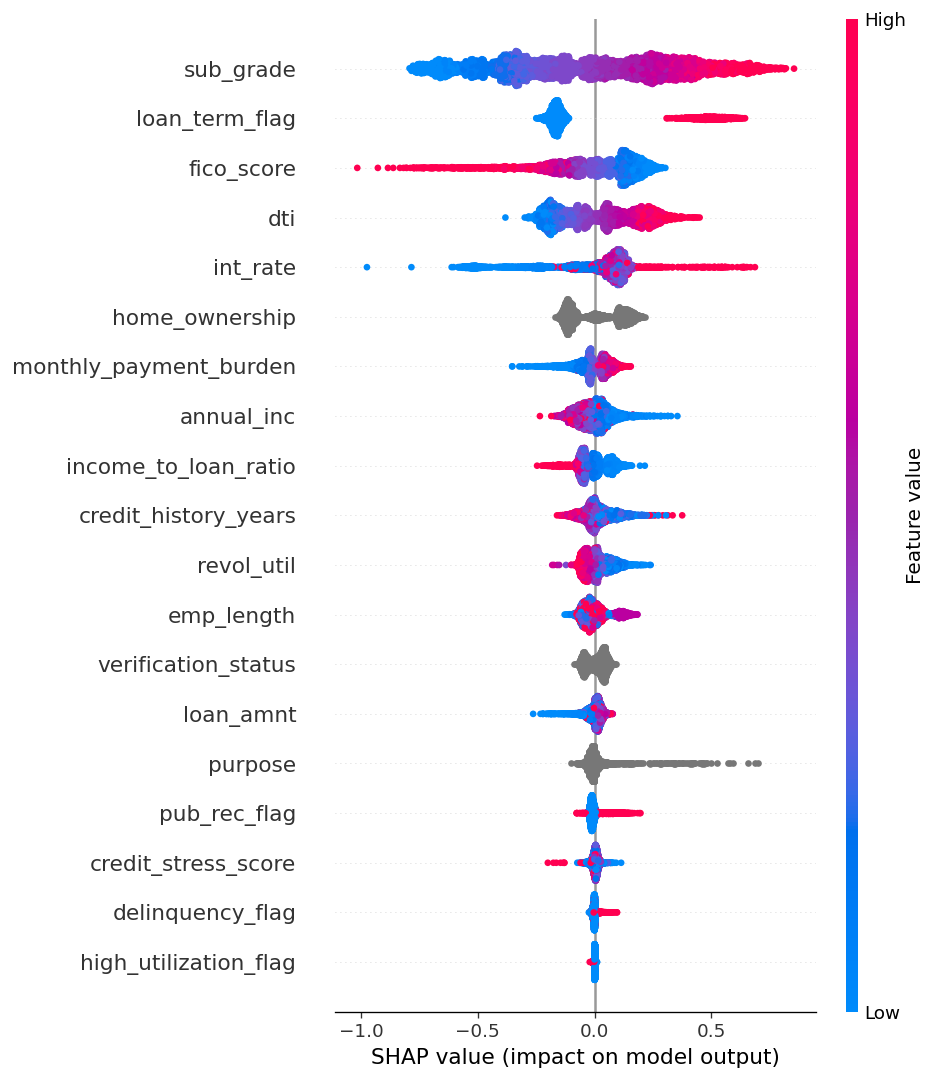

In [5]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()


### 1.2 SHAP Bar Plot

The "at-a-glance" ranking — mean absolute SHAP value per feature, i.e. how much each feature
moves the predicted PD on average, regardless of direction.


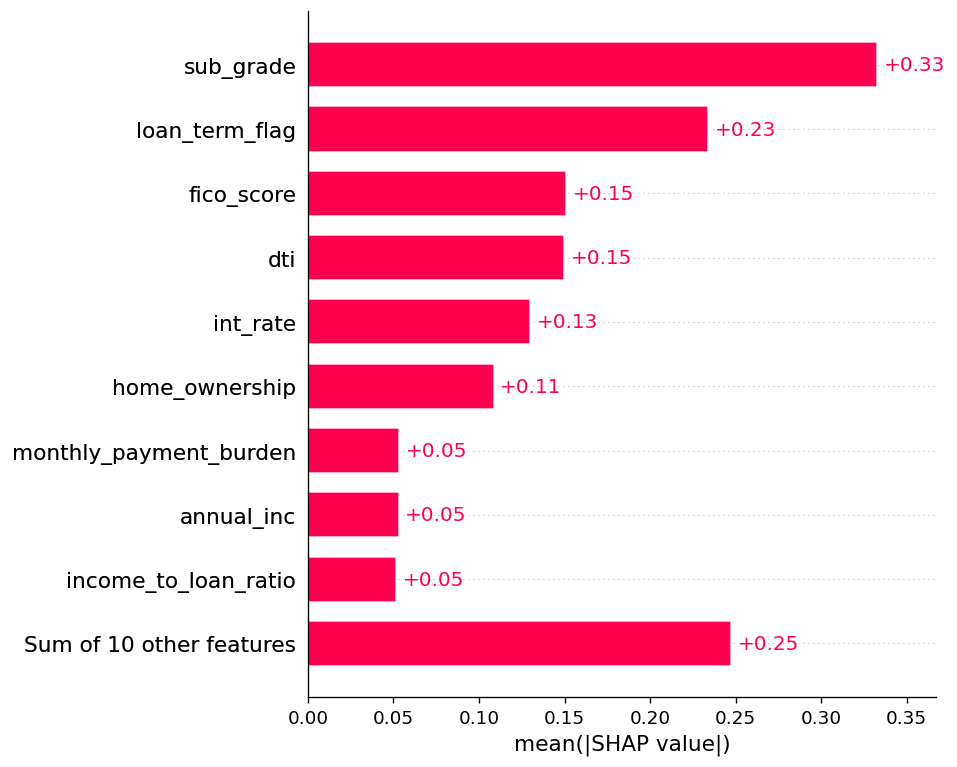

In [6]:
shap.plots.bar(shap_values, show=False)
plt.tight_layout()
plt.show()


### 1.3 SHAP Dependence Plots

How does the model's view of risk change as each feature value changes? These plots are the
fastest way to confirm the model has learned relationships consistent with underwriting
intuition.


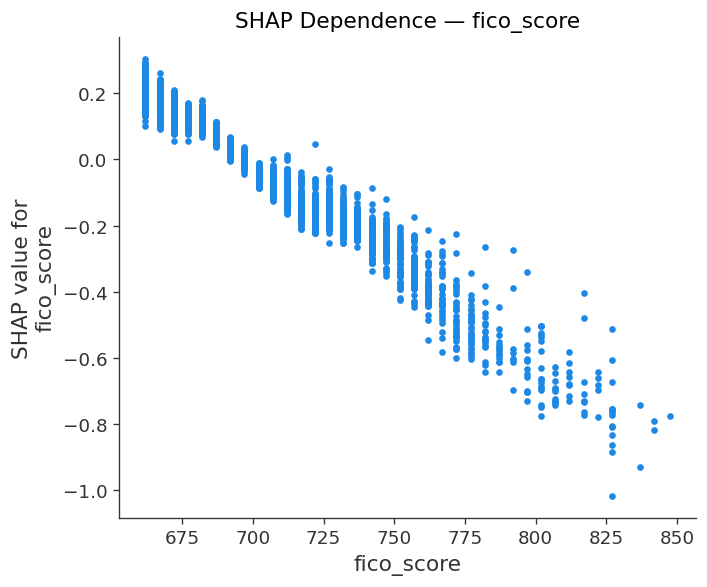

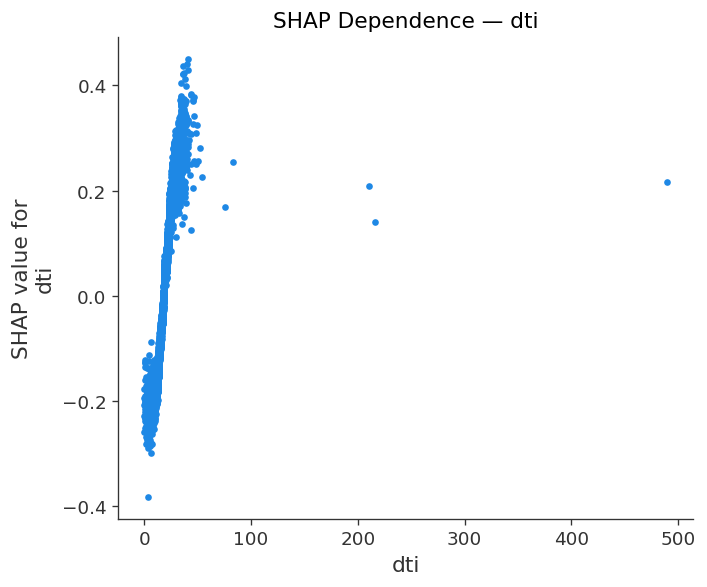

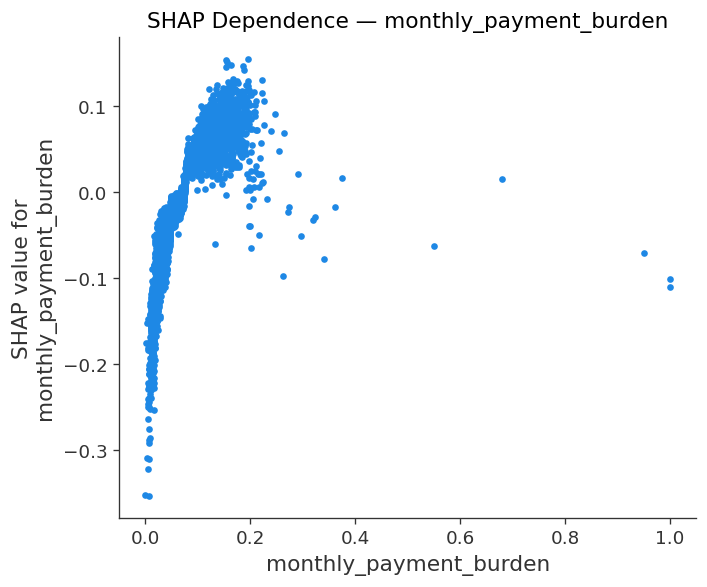

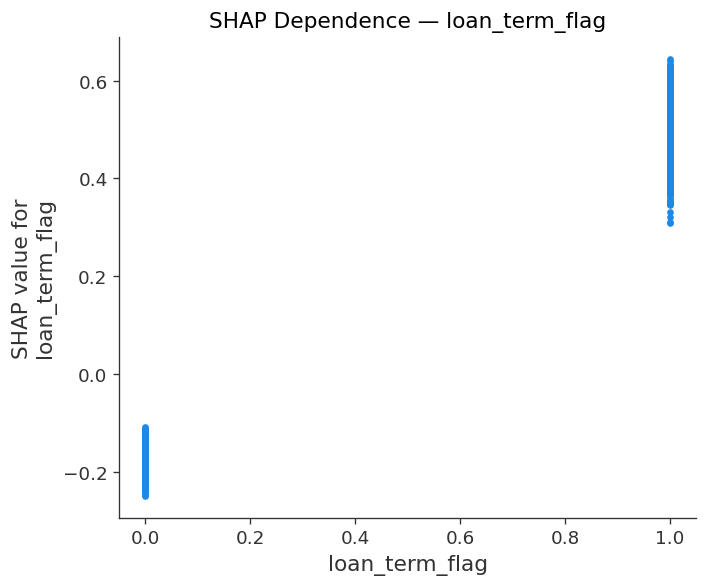

In [7]:
for feat in ['fico_score', 'dti', 'monthly_payment_burden', 'loan_term_flag']:
    shap.dependence_plot(feat, shap_values.values, X_sample, show=False, interaction_index=None)
    plt.title(f'SHAP Dependence — {feat}')
    plt.tight_layout()
    plt.show()


**Expected patterns** (and what they mean in underwriting terms):
- **`fico_score`**: SHAP values should trend downward as FICO increases — a higher bureau
  score consistently lowers predicted PD, exactly as underwriting guidelines assume.
- **`dti`**: SHAP values should trend upward as DTI increases — borrowers already carrying
  more debt relative to income are riskier, all else equal.
- **`monthly_payment_burden`**: similarly upward-sloping — a loan that consumes a larger share
  of monthly income leaves less buffer for shocks.
- **`loan_term_flag`**: a step up from 36-month (0) to 60-month (1) loans — longer terms
  carry materially higher risk, consistent with the Phase B/C finding.

### 1.4 Individual Borrower Explanations

One **low-risk** borrower (bottom of the `pd_score` distribution within the sample) and one
**high-risk** borrower (top of the distribution) — showing exactly which features drove each
score up or down.


Low-risk borrower  -> PD = 0.00%


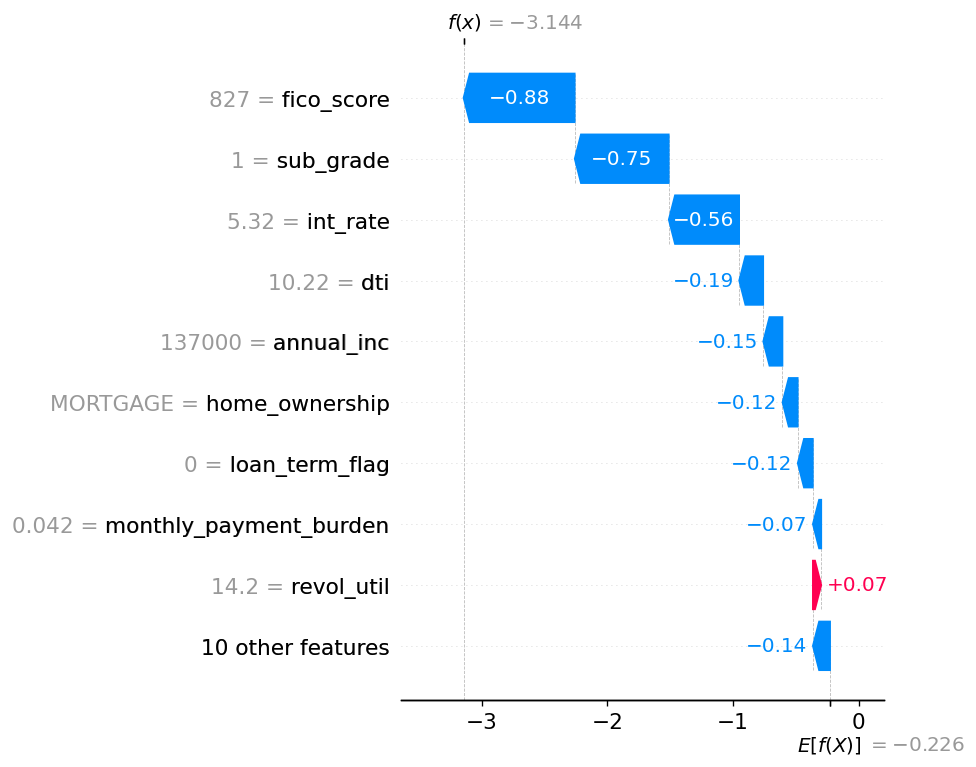

In [8]:
low_idx = sample['pd_score'].values.argmin()
high_idx = sample['pd_score'].values.argmax()

print(f"Low-risk borrower  -> PD = {sample['pd_score'].values[low_idx]:.2%}")
shap.plots.waterfall(shap_values[low_idx], show=False)
plt.tight_layout()
plt.show()


High-risk borrower -> PD = 80.00%


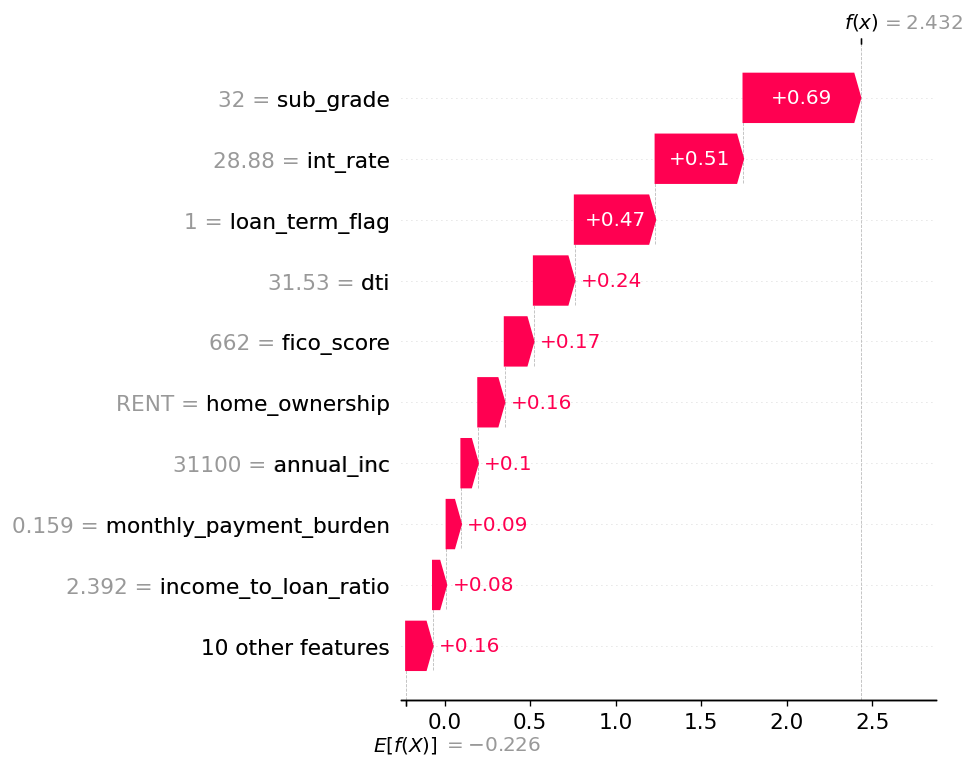

In [9]:
print(f"High-risk borrower -> PD = {sample['pd_score'].values[high_idx]:.2%}")
shap.plots.waterfall(shap_values[high_idx], show=False)
plt.tight_layout()
plt.show()


**Business takeaway:** the low-risk borrower's score is pulled down primarily by a strong
`fico_score`, low `dti`, and/or a 36-month term — the high-risk borrower's score is pushed up
by the opposite combination (weak `sub_grade`, high `credit_stress_score`, 60-month term,
etc.). Each waterfall is, in effect, a plain-language adverse-action explanation.

### 1.5 Exports


In [10]:
# outputs/shap_summary.csv -- mean |SHAP value| per feature (bar plot data)
mean_abs_shap = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_abs_shap.to_csv(os.path.join(output_dir, 'shap_summary.csv'), index=False)
mean_abs_shap


,feature,mean_abs_shap
0,sub_grade,0.332924
1,loan_term_flag,0.233971
2,fico_score,0.151067
3,dti,0.149970
4,int_rate,0.129882
5,home_ownership,0.108489
6,monthly_payment_burden,0.053377
7,annual_inc,0.052994
8,income_to_loan_ratio,0.051477
9,credit_history_years,0.046510


In [11]:
# outputs/shap_executive_summary.csv -- Feature, Average Impact, Direction, Business Interpretation
business_interpretation = {
    'sub_grade':              'Higher (riskier) LendingClub sub-grade increases predicted default risk.',
    'loan_term_flag':         '60-month loans carry materially higher default risk than 36-month loans.',
    'int_rate':               'Higher market-assigned interest rate signals higher priced-in risk.',
    'fico_score':             'Higher bureau credit score reduces predicted default risk.',
    'dti':                    'Higher debt-to-income ratio increases predicted default risk.',
    'annual_inc':             'Higher annual income reduces predicted default risk.',
    'home_ownership':         'Renting (vs owning/mortgage) is associated with higher default risk.',
    'credit_history_years':   'Longer credit history reduces predicted default risk.',
    'monthly_payment_burden': 'A loan payment consuming more of monthly income increases default risk.',
    'emp_length':             'Shorter employment tenure is associated with higher default risk.',
    'revol_util':             'Higher revolving credit utilization increases default risk.',
    'income_to_loan_ratio':   'A smaller loan relative to income reduces default risk.',
    'loan_amnt':              'Larger loan amounts are associated with modestly higher default risk.',
    'purpose':                'Loan purpose has a modest effect, varying by stated reason for borrowing.',
    'verification_status':    'Income verification status has a modest, mixed effect on default risk.',
    'credit_stress_score':    'Higher combined DTI/utilization stress increases default risk.',
    'pub_rec_flag':           'Any public derogatory record increases default risk.',
    'delinquency_flag':       'A recent delinquency increases default risk.',
    'high_utilization_flag':  'Utilization above 75% has a small additional risk-increasing effect.',
}

# Direction: correlation sign between the feature's (numeric-encoded) value and its SHAP value
directions = {}
for i, feat in enumerate(X_sample.columns):
    col = X_sample[feat]
    if not pd.api.types.is_numeric_dtype(col):
        # encode categoricals by their mean target rate for a directional proxy
        rate_map = sample.groupby(feat)['target'].mean()
        col = X_sample[feat].map(rate_map)
    corr = np.corrcoef(col.astype(float), shap_values.values[:, i])[0, 1]
    directions[feat] = 'Increases Risk' if corr > 0 else 'Decreases Risk'

shap_executive_summary = mean_abs_shap.copy()
shap_executive_summary.columns = ['Feature', 'Average Impact']
shap_executive_summary['Direction'] = shap_executive_summary['Feature'].map(directions)
shap_executive_summary['Business Interpretation'] = shap_executive_summary['Feature'].map(business_interpretation)

shap_executive_summary.to_csv(os.path.join(output_dir, 'shap_executive_summary.csv'), index=False)
shap_executive_summary


,Feature,Average Impact,Direction,Business Interpretation
0,sub_grade,0.332924,Increases Risk,Higher (riskier) LendingClub sub-grade increas...
1,loan_term_flag,0.233971,Increases Risk,60-month loans carry materially higher default...
2,fico_score,0.151067,Decreases Risk,Higher bureau credit score reduces predicted d...
3,dti,0.149970,Increases Risk,Higher debt-to-income ratio increases predicte...
4,int_rate,0.129882,Increases Risk,Higher market-assigned interest rate signals h...
5,home_ownership,0.108489,Increases Risk,Renting (vs owning/mortgage) is associated wit...
6,monthly_payment_burden,0.053377,Increases Risk,A loan payment consuming more of monthly incom...
7,annual_inc,0.052994,Decreases Risk,Higher annual income reduces predicted default...
8,income_to_loan_ratio,0.051477,Decreases Risk,A smaller loan relative to income reduces defa...
9,credit_history_years,0.046510,Decreases Risk,Longer credit history reduces predicted defaul...


**What decision would a risk manager make from this?** This section is the artifact a
model-validation or fair-lending review team would request first: confirmation that the
model's drivers are explainable, directionally sane, and consistent with documented
underwriting policy — before approving the model's PD output for use in segmentation,
Expected Loss, and pricing (Sections 3-5).


---
## Section 2 — Probability of Default (PD) Distribution Analysis

Using `pd_score` (Calibrated CatBoost) for the full 2016 validation portfolio (293,095 loans).


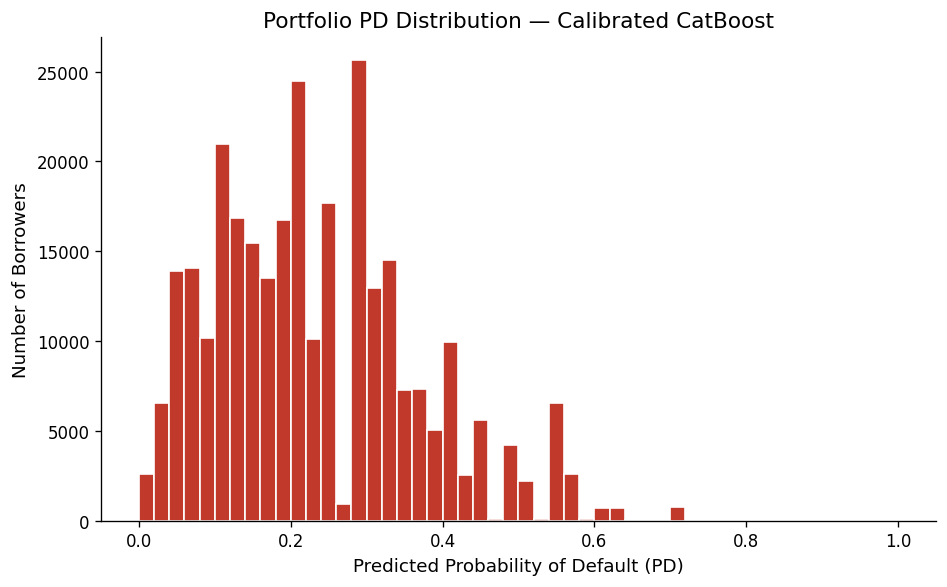

count    293095.000000
mean          0.232832
std           0.135537
min           0.000000
10%           0.067034
25%           0.120143
50%           0.213254
75%           0.312982
90%           0.409005
99%           0.578892
max           1.000000
Name: pd_score, dtype: float64

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(val_df['pd_score'], bins=50, color=COLOR_DEFAULT, edgecolor='white')
plt.xlabel('Predicted Probability of Default (PD)')
plt.ylabel('Number of Borrowers')
plt.title('Portfolio PD Distribution — Calibrated CatBoost')
plt.tight_layout()
plt.show()

val_df['pd_score'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])


In [13]:
for threshold in [0.10, 0.20, 0.35, 0.50]:
    share = (val_df['pd_score'] >= threshold).mean()
    print(f'Share of portfolio with PD >= {threshold:.0%}: {share:.2%}')


Share of portfolio with PD >= 10%: 83.86%
Share of portfolio with PD >= 20%: 55.34%
Share of portfolio with PD >= 35%: 18.63%
Share of portfolio with PD >= 50%: 4.69%


**Is risk concentrated?** The distribution is expected to be right-skewed: most borrowers
cluster at low-to-moderate PD, with a smaller tail of borrowers at materially elevated PD.
The thresholds above quantify exactly how much of the portfolio sits in each risk zone and
directly motivate the segmentation bands in Section 3.

**What decision would a risk manager make from this?** If, say, fewer than 5% of borrowers
exceed PD = 35%, "Critical Risk" is correctly a small, high-priority segment rather than a
broad catch-all — informing how aggressively underwriting resources should be allocated.


---
## Section 3 — Risk Segmentation

### Locked risk bands

| Segment | PD Range |
|---|---|
| Low Risk | PD < 10% |
| Medium Risk | 10% <= PD < 20% |
| High Risk | 20% <= PD < 35% |
| Critical Risk | PD >= 35% |

These bands are fixed per the approved plan and only adjusted if a segment is effectively
empty (checked below).


In [14]:
bins = [-0.001, 0.10, 0.20, 0.35, 1.0]
labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
val_df['risk_segment'] = pd.cut(val_df['pd_score'], bins=bins, labels=labels)

segment_counts = val_df['risk_segment'].value_counts().reindex(labels)
print(segment_counts)
print('\nAny empty segments?', (segment_counts == 0).any())


risk_segment
Low Risk          47316
Medium Risk       83566
High Risk        107605
Critical Risk     54608
Name: count, dtype: int64

Any empty segments? False


In [15]:
risk_segments = val_df.groupby('risk_segment', observed=True).agg(
    borrower_count=('pd_score', 'size'),
    actual_default_rate=('target', 'mean'),
    avg_loan_amnt=('loan_amnt', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_pd=('pd_score', 'mean'),
).reindex(labels)

risk_segments['portfolio_share'] = risk_segments['borrower_count'] / risk_segments['borrower_count'].sum()
risk_segments = risk_segments[['borrower_count', 'portfolio_share', 'actual_default_rate', 'avg_pd', 'avg_loan_amnt', 'avg_int_rate']]
risk_segments = risk_segments.round(4)

risk_segments.to_csv(os.path.join(output_dir, 'risk_segments.csv'))
risk_segments


,borrower_count,portfolio_share,actual_default_rate,avg_pd,avg_loan_amnt,avg_int_rate
risk_segment,,,,,,
Low Risk,47316,0.1614,0.0597,0.0597,14227.2112,7.0870
Medium Risk,83566,0.2851,0.1461,0.1461,12405.4460,10.4951
High Risk,107605,0.3671,0.2668,0.2668,14171.3429,14.3245
Critical Risk,54608,0.1863,0.4486,0.4486,18412.8621,19.8114


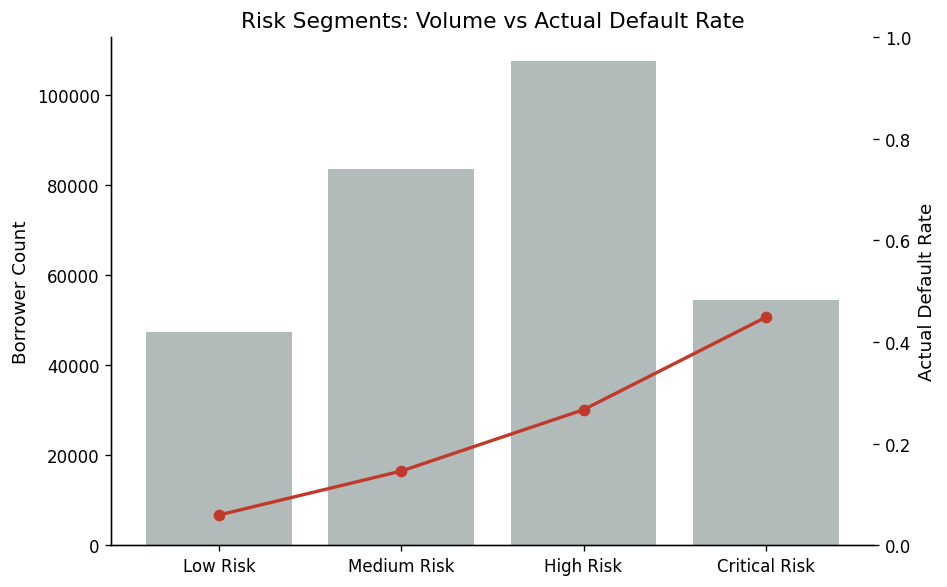

In [16]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(risk_segments.index, risk_segments['borrower_count'], color=COLOR_NEUTRAL, alpha=0.6, label='Borrower Count')
ax1.set_ylabel('Borrower Count')

ax2 = ax1.twinx()
ax2.plot(risk_segments.index, risk_segments['actual_default_rate'], color=COLOR_DEFAULT, marker='o', linewidth=2, label='Actual Default Rate')
ax2.set_ylabel('Actual Default Rate')
ax2.set_ylim(0, 1)

plt.title('Risk Segments: Volume vs Actual Default Rate')
fig.tight_layout()
plt.show()


**Validation check:** `actual_default_rate` should increase monotonically from Low Risk to
Critical Risk. If it does, the calibrated PD bands are correctly separating realized
outcomes — not just predicted scores.

### Risk Action Framework

| Segment | Recommended Action |
|---|---|
| **Low Risk** | Auto Approve |
| **Medium Risk** | Standard Approval |
| **High Risk** | Manual Review |
| **Critical Risk** | Decline / Reprice |


In [17]:
risk_action_framework = pd.DataFrame({
    'Risk Segment': labels,
    'PD Range': ['< 10%', '10% - 20%', '20% - 35%', '>= 35%'],
    'Recommended Action': ['Auto Approve', 'Standard Approval', 'Manual Review', 'Decline / Reprice'],
})
risk_action_framework


,Risk Segment,PD Range,Recommended Action
0,Low Risk,< 10%,Auto Approve
1,Medium Risk,10% - 20%,Standard Approval
2,High Risk,20% - 35%,Manual Review
3,Critical Risk,>= 35%,Decline / Reprice


**What decision would a risk manager make from this?** This table *is* the operating
policy — it converts a continuous PD score into one of four concrete underwriting actions,
which is exactly how a credit policy engine consumes a model's output in production.


---
## Section 4 — Expected Loss Framework

**Formula:** `Expected Loss = PD x LGD x EAD`

| Component | Definition | Value |
|---|---|---|
| PD | Calibrated CatBoost probability (`pd_score`) | per-borrower |
| LGD | Loss Given Default | 60% (fixed, matches Phase D business impact assumption) |
| EAD | Exposure at Default | `loan_amnt` |

Kept deliberately simple and transparent — this is a methodology demonstration, not a
calibrated provisioning model.


In [18]:
LGD = 0.60
val_df['expected_loss'] = val_df['pd_score'] * LGD * val_df['loan_amnt']

total_el = val_df['expected_loss'].sum()
avg_el = val_df['expected_loss'].mean()

print(f'Total Portfolio Expected Loss: ${total_el:,.0f}')
print(f'Average Expected Loss per Borrower: ${avg_el:,.2f}')


Total Portfolio Expected Loss: $634,920,018
Average Expected Loss per Borrower: $2,166.26


In [19]:
el_by_segment = val_df.groupby('risk_segment', observed=True).agg(
    borrower_count=('expected_loss', 'size'),
    total_expected_loss=('expected_loss', 'sum'),
    avg_expected_loss=('expected_loss', 'mean'),
).reindex(labels)

el_by_segment['el_share'] = el_by_segment['total_expected_loss'] / el_by_segment['total_expected_loss'].sum()
el_by_segment = el_by_segment.round(2)

expected_loss_analysis = el_by_segment.copy()
expected_loss_analysis.loc['TOTAL PORTFOLIO'] = [
    val_df.shape[0], total_el, avg_el, 1.0
]
expected_loss_analysis.to_csv(os.path.join(output_dir, 'expected_loss_analysis.csv'))
expected_loss_analysis


,borrower_count,total_expected_loss,avg_expected_loss,el_share
risk_segment,,,,
Low Risk,47316.0,2.370656e+07,501.030000,0.04
Medium Risk,83566.0,9.085299e+07,1087.200000,0.14
High Risk,107605.0,2.469136e+08,2294.630000,0.39
Critical Risk,54608.0,2.734468e+08,5007.450000,0.43
TOTAL PORTFOLIO,293095.0,6.349200e+08,2166.260147,1.00


**What decision would a risk manager make from this?** `total_expected_loss` is the figure
that feeds loan-loss provisioning. `el_share` by segment shows where that provisioning need
*comes from* — typically a small share of borrowers (High/Critical) account for a
disproportionate share of total EL, which is the central finding visualized in Section 6.


---
## Section 5 — Risk-Based Pricing Engine

**Formula:** `Recommended APR = Funding Cost + Expected Loss Rate + Margin`

| Component | Value | Notes |
|---|---|---|
| Funding Cost | 4% | Fixed assumption — cost of capital to the lender |
| Expected Loss Rate | `pd_score x LGD` | Per-borrower, expressed as a rate (not a dollar amount) |
| Margin | 3% | Fixed assumption — target profit margin |

This is a **business exercise**, not a financial-engineering exercise: the goal is to show
that the model's PD output can be translated directly into a pricing recommendation, and to
compare that recommendation against LendingClub's actual `int_rate`.


In [20]:
FUNDING_COST = 0.04
MARGIN = 0.03

val_df['expected_loss_rate'] = val_df['pd_score'] * LGD
val_df['recommended_apr'] = FUNDING_COST + val_df['expected_loss_rate'] + MARGIN

pricing_recommendations = val_df.groupby('risk_segment', observed=True).agg(
    borrower_count=('pd_score', 'size'),
    avg_pd=('pd_score', 'mean'),
    avg_expected_loss_rate=('expected_loss_rate', 'mean'),
    avg_recommended_apr=('recommended_apr', 'mean'),
    avg_actual_int_rate=('int_rate', 'mean'),
).reindex(labels)

pricing_recommendations['actual_int_rate'] = pricing_recommendations['avg_actual_int_rate'] / 100
pricing_recommendations['pricing_gap'] = pricing_recommendations['avg_recommended_apr'] - pricing_recommendations['actual_int_rate']
pricing_recommendations = pricing_recommendations.drop(columns=['avg_actual_int_rate']).round(4)

pricing_recommendations.to_csv(os.path.join(output_dir, 'pricing_recommendations.csv'))
pricing_recommendations


,borrower_count,avg_pd,avg_expected_loss_rate,avg_recommended_apr,actual_int_rate,pricing_gap
risk_segment,,,,,,
Low Risk,47316,0.0597,0.0358,0.1058,0.0709,0.0350
Medium Risk,83566,0.1461,0.0876,0.1576,0.1050,0.0527
High Risk,107605,0.2668,0.1601,0.2301,0.1432,0.0869
Critical Risk,54608,0.4486,0.2691,0.3391,0.1981,0.1410


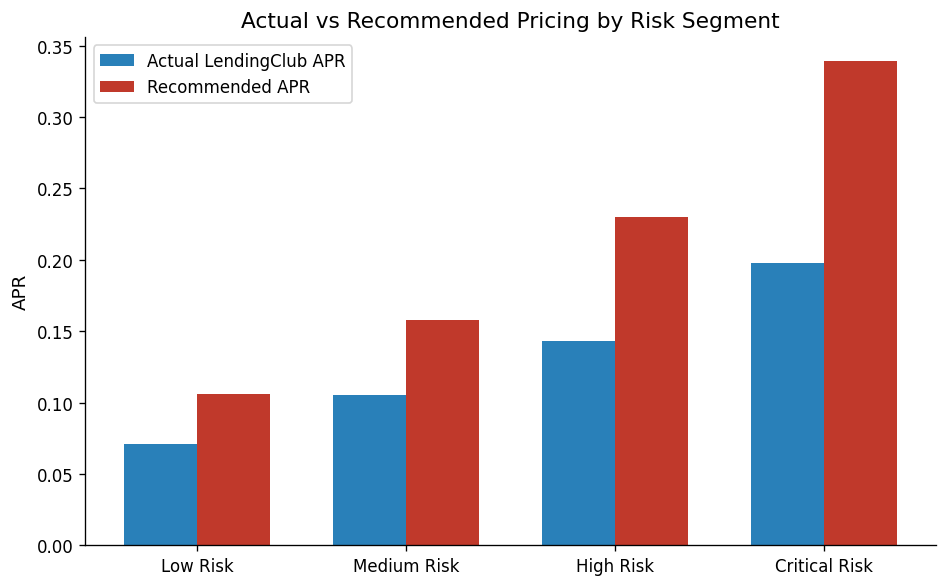

In [21]:
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, pricing_recommendations['actual_int_rate'], width, label='Actual LendingClub APR', color=COLOR_NONDEFAULT)
plt.bar(x + width/2, pricing_recommendations['avg_recommended_apr'], width, label='Recommended APR', color=COLOR_DEFAULT)
plt.xticks(x, labels)
plt.ylabel('APR')
plt.title('Actual vs Recommended Pricing by Risk Segment')
plt.legend()
plt.tight_layout()
plt.show()


**Business interpretation:** a positive `pricing_gap` means the model's PD-based view of
risk implies LendingClub's actual rate undercharges that segment relative to its expected
loss; a negative gap implies the segment may be overpriced relative to its risk. The
direction and size of these gaps — particularly for High and Critical Risk — is the core
finding of this section.

**What decision would a risk manager make from this?** Segments with a large positive gap
are candidates for repricing (higher APR) or tighter approval criteria; segments with a
negative gap represent room for more competitive pricing without additional risk.


---
## Section 6 — Portfolio Risk Analysis & Concentration

**Core executive visualization:** Portfolio Share vs Expected Loss Share, by Risk Segment.
This single chart answers the three questions a risk committee asks first: which segment
carries the most volume, which carries the most expected loss, and where is the gap between
the two largest (i.e., where is risk most concentrated relative to volume)?


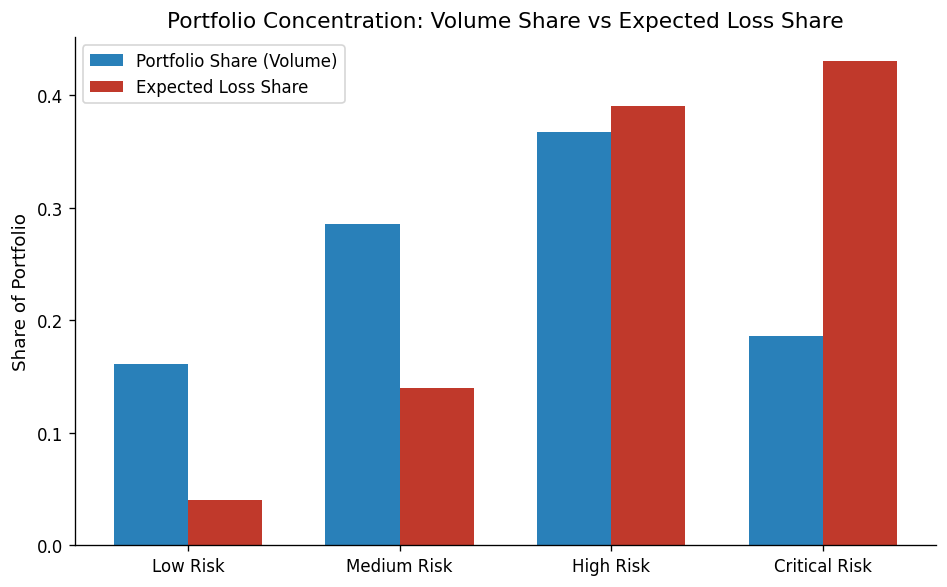

,Portfolio Share,Expected Loss Share
risk_segment,,
Low Risk,0.1614,0.04
Medium Risk,0.2851,0.14
High Risk,0.3671,0.39
Critical Risk,0.1863,0.43


In [22]:
concentration = pd.DataFrame({
    'Portfolio Share': risk_segments['portfolio_share'],
    'Expected Loss Share': el_by_segment['el_share'],
}).reindex(labels)

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, concentration['Portfolio Share'], width, label='Portfolio Share (Volume)', color=COLOR_NONDEFAULT)
plt.bar(x + width/2, concentration['Expected Loss Share'], width, label='Expected Loss Share', color=COLOR_DEFAULT)
plt.xticks(x, labels)
plt.ylabel('Share of Portfolio')
plt.title('Portfolio Concentration: Volume Share vs Expected Loss Share')
plt.legend()
plt.tight_layout()
plt.show()

concentration.round(4)


**Which segment contributes most expected loss? Which generates most volume? Which
deserves underwriting review?**

- **Most volume:** typically Low and Medium Risk together — the bulk of the book.
- **Most Expected Loss:** typically High and Critical Risk — a much larger share of EL than
  their share of volume, the visual definition of risk concentration.
- **Underwriting review priority:** the segment where the *gap* between EL share and
  portfolio share is largest but volume is still meaningful — usually **High Risk** (large
  enough to matter, risky enough to act on, unlike Critical Risk which may be small enough to
  simply decline outright per the Risk Action Framework).

**What decision would a risk manager make from this?** Resource allocation — manual
underwriting review capacity should be weighted toward the segment(s) where this chart shows
the largest EL-share-to-volume-share gap, maximizing risk reduction per loan reviewed.


---
## Section 7 — Stress Testing

Three scenarios, applied as simple multipliers to `pd_score` (clipped to valid probability
range), with LGD and EAD held constant:

| Scenario | PD Multiplier |
|---|---|
| Base Case | 1.0x |
| Mild Recession | 1.3x |
| Severe Recession | 1.7x |


In [23]:
scenarios = {'Base Case': 1.0, 'Mild Recession': 1.3, 'Severe Recession': 1.7}

stress_results = []
for name, multiplier in scenarios.items():
    stressed_pd = np.clip(val_df['pd_score'] * multiplier, 0, 1)
    stressed_el = (stressed_pd * LGD * val_df['loan_amnt']).sum()
    stress_results.append({
        'Scenario': name,
        'PD Multiplier': multiplier,
        'Portfolio Expected Loss': stressed_el,
        'Change vs Base (%)': np.nan,
    })

stress_test_results = pd.DataFrame(stress_results)
base_el = stress_test_results.loc[0, 'Portfolio Expected Loss']
stress_test_results['Change vs Base (%)'] = (
    (stress_test_results['Portfolio Expected Loss'] / base_el - 1) * 100
).round(2)
stress_test_results['Portfolio Expected Loss'] = stress_test_results['Portfolio Expected Loss'].round(2)

stress_test_results.to_csv(os.path.join(output_dir, 'stress_test_results.csv'), index=False)
stress_test_results


,Scenario,PD Multiplier,Portfolio Expected Loss,Change vs Base (%)
0,Base Case,1.0,6.349200e+08,0.00
1,Mild Recession,1.3,8.253601e+08,29.99
2,Severe Recession,1.7,1.076235e+09,69.51


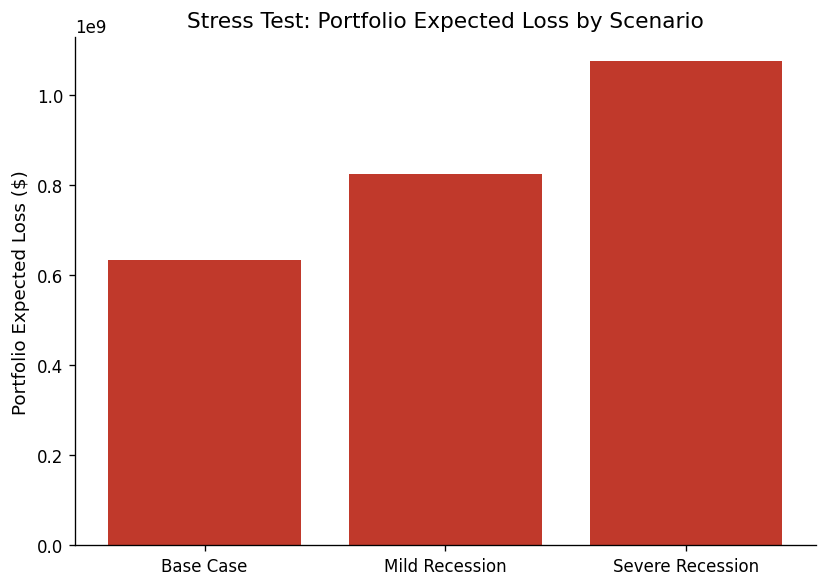

In [24]:
plt.figure(figsize=(7, 5))
plt.bar(stress_test_results['Scenario'], stress_test_results['Portfolio Expected Loss'], color=COLOR_DEFAULT)
plt.ylabel('Portfolio Expected Loss ($)')
plt.title('Stress Test: Portfolio Expected Loss by Scenario')
plt.tight_layout()
plt.show()


**What decision would a risk manager make from this?** The Mild/Severe Recession columns
quantify the additional capital buffer the institution would need to absorb under adverse
conditions, using only the existing PD model and a simple stress multiplier — the same
"shock the inputs, hold the model fixed" logic used in CCAR/ICAAP-style stress testing,
deliberately kept simple here.


---
## Section 8 — Summary & Streamlit Export Index

### Exported artifacts

| File | Streamlit Use |
|---|---|
| `outputs/risk_segments.csv` | Segment summary table / segment selector |
| `outputs/expected_loss_analysis.csv` | Expected Loss summary cards & by-segment chart |
| `outputs/pricing_recommendations.csv` | Pricing comparison chart (actual vs recommended APR) |
| `outputs/stress_test_results.csv` | Stress-test scenario chart |
| `outputs/shap_summary.csv` | "Top model drivers" bar chart |
| `outputs/shap_executive_summary.csv` | "Why this score?" explainer table |

### Answering the five Phase E objectives

1. **How should borrowers be segmented by risk?** Four PD-based bands (Low / Medium / High /
   Critical), validated against actual default rates (Section 3) and paired with a concrete
   Risk Action Framework.
2. **What is the expected loss of each borrower?** `PD x LGD x EAD`, aggregated to a total
   portfolio Expected Loss and broken down by segment (Section 4).
3. **What price should be charged for risk?** A transparent `Funding Cost + Expected Loss
   Rate + Margin` formula, compared segment-by-segment against LendingClub's actual pricing
   (Section 5).
4. **What does portfolio risk look like?** A small share of borrowers (High/Critical Risk)
   account for a disproportionate share of total Expected Loss relative to their volume
   (Section 6) — and this concentration grows further under stress (Section 7).
5. **How would a lending institution use these outputs?** Segment -> action (auto-approve,
   review, decline/reprice), Expected Loss -> provisioning, pricing gaps -> repricing
   decisions, stress results -> capital planning.

### Interview test

*"Why use SHAP if you already have CatBoost's feature importance from Phase D?"*

Feature importance is a single global, unsigned ranking — it says `sub_grade` matters a lot,
but not *in which direction* or *for which borrower*. SHAP is per-borrower and signed: it
shows that for *this specific applicant*, a high `dti` added 4 points of PD while a strong
`fico_score` subtracted 6 — the exact decomposition needed for adverse-action explanations,
model validation, and the executive storytelling this notebook is built around.
